In [1]:
import os
import sys
src_path = '../../../src'
if src_path not in sys.path:
    sys.path.append(src_path)
import numpy as np
import pandas as pd
from configs import SetupEnum, MeasurementDataEnum, ErrorEnum
from kalman_filters.particle_filter import ResamplingAlgorithms
from parameter_tuners.particle_filter_parameter_tuner import ParticleFilterParameterTuner
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

In [2]:
# n_samples = np.logspace(1.0, 4.0, num=10).tolist()
algorithms = [ResamplingAlgorithms.MULTINOMIAL, 
              ResamplingAlgorithms.RESIDUAL, 
              ResamplingAlgorithms.STRATIFIED, 
              ResamplingAlgorithms.SYSTEMATIC]
# n_samples = np.logspace(1.0, 4.0, num=4).tolist()
n_samples = [int(n) for n in np.logspace(5, 12, base=2, num=8).tolist()]

params = {
    "n_samples": n_samples,
    "algorithms": algorithms,
}
n_samples

[32, 64, 128, 256, 512, 1024, 2048, 4096]

In [3]:
resampling_algorithm_str = {
    ResamplingAlgorithms.MULTINOMIAL: "MULTINOMIAL", 
    ResamplingAlgorithms.RESIDUAL: "RESIDUAL", 
    ResamplingAlgorithms.STRATIFIED: "STRATIFIED", 
    ResamplingAlgorithms.SYSTEMATIC: "SYSTEMATIC"
}

root_path = "../../../"

file_export_path = os.path.join(root_path, "exports/particle_filter")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
kitti_dataset = "0033"

run_filter = True

error_weight = 0.8

In [4]:
best_params = []
best_params_0 = []
best_params_10 = []
best_params_20 = []
best_params_30 = []
best_params_40 = []

------

# No dropout measurement data

## Setup1 (IMU, VO)

In [5]:
tuner_setup1 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    measurement_type=MeasurementDataEnum.ALL_DATA,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.,
    gps_dropout_ratio=0.
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [6]:
if run_filter:
    tuner_setup1.run()
else:
    tuner_setup1.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [11:04<00:00, 83.11s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [08:59<00:00, 67.49s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [09:48<00:00, 73.62s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [09:16<00:00, 69.61s/it]

Experiment finished.


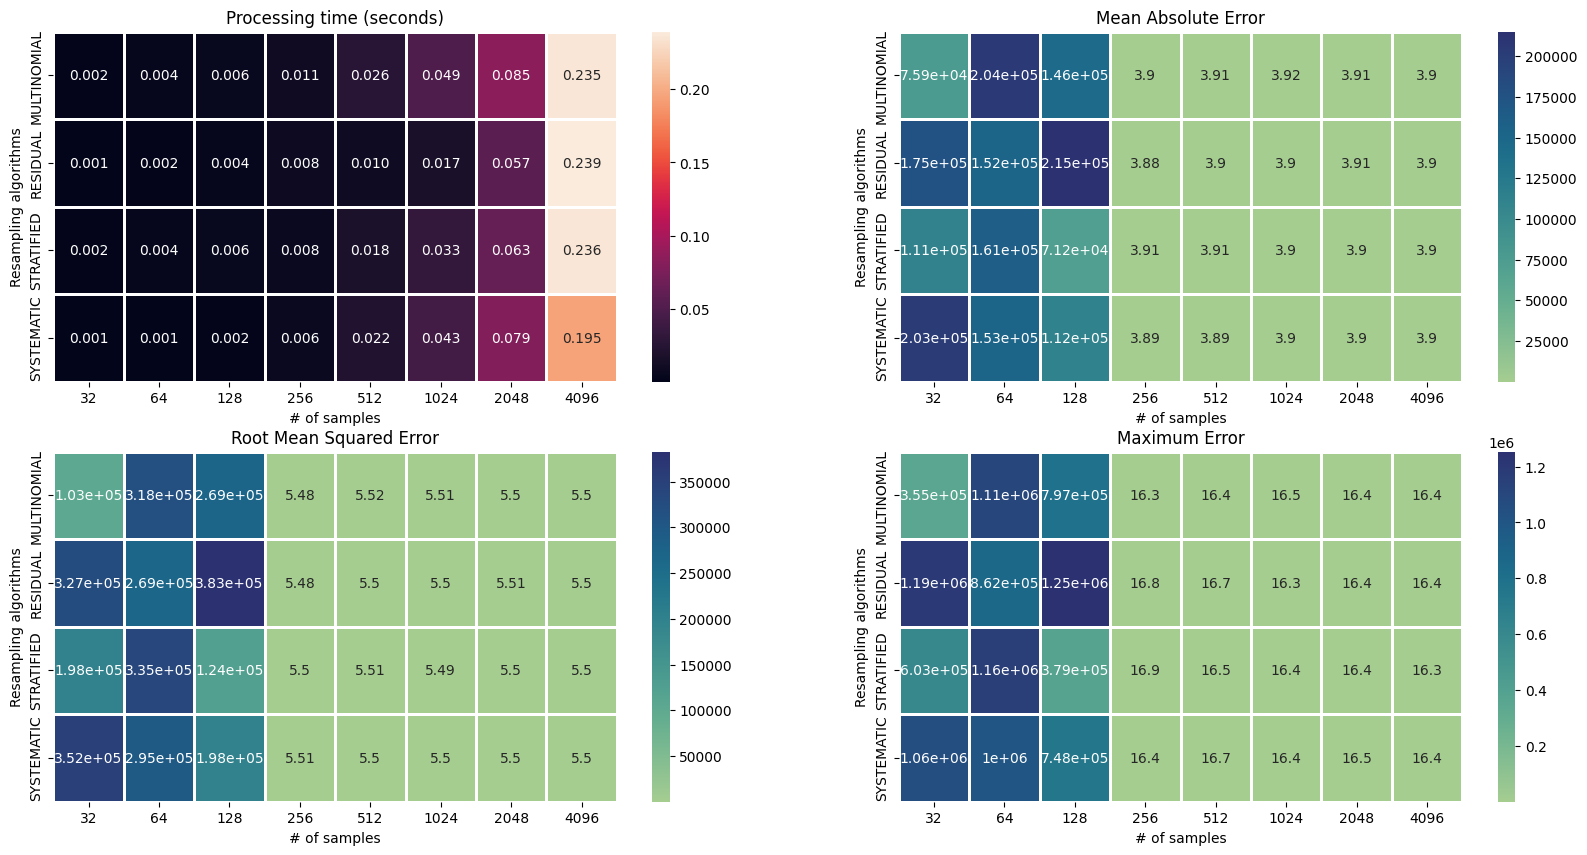

In [7]:
tuner_setup1.plot_results()

In [8]:
params_1_0, df_1_0 = tuner_setup1.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append(params_1_0)

In [9]:
df_1_0

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,256,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [10]:
tuner_setup2 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.,
    gps_dropout_ratio=0.
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [11]:
if run_filter:
    tuner_setup2.run()
else:
    tuner_setup2.load_df()

Resampling by $MULTINOMIAL


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [15:08<00:00, 113.61s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [11:45<00:00, 88.23s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [11:26<00:00, 85.87s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [09:10<00:00, 68.77s/it]

Experiment finished.


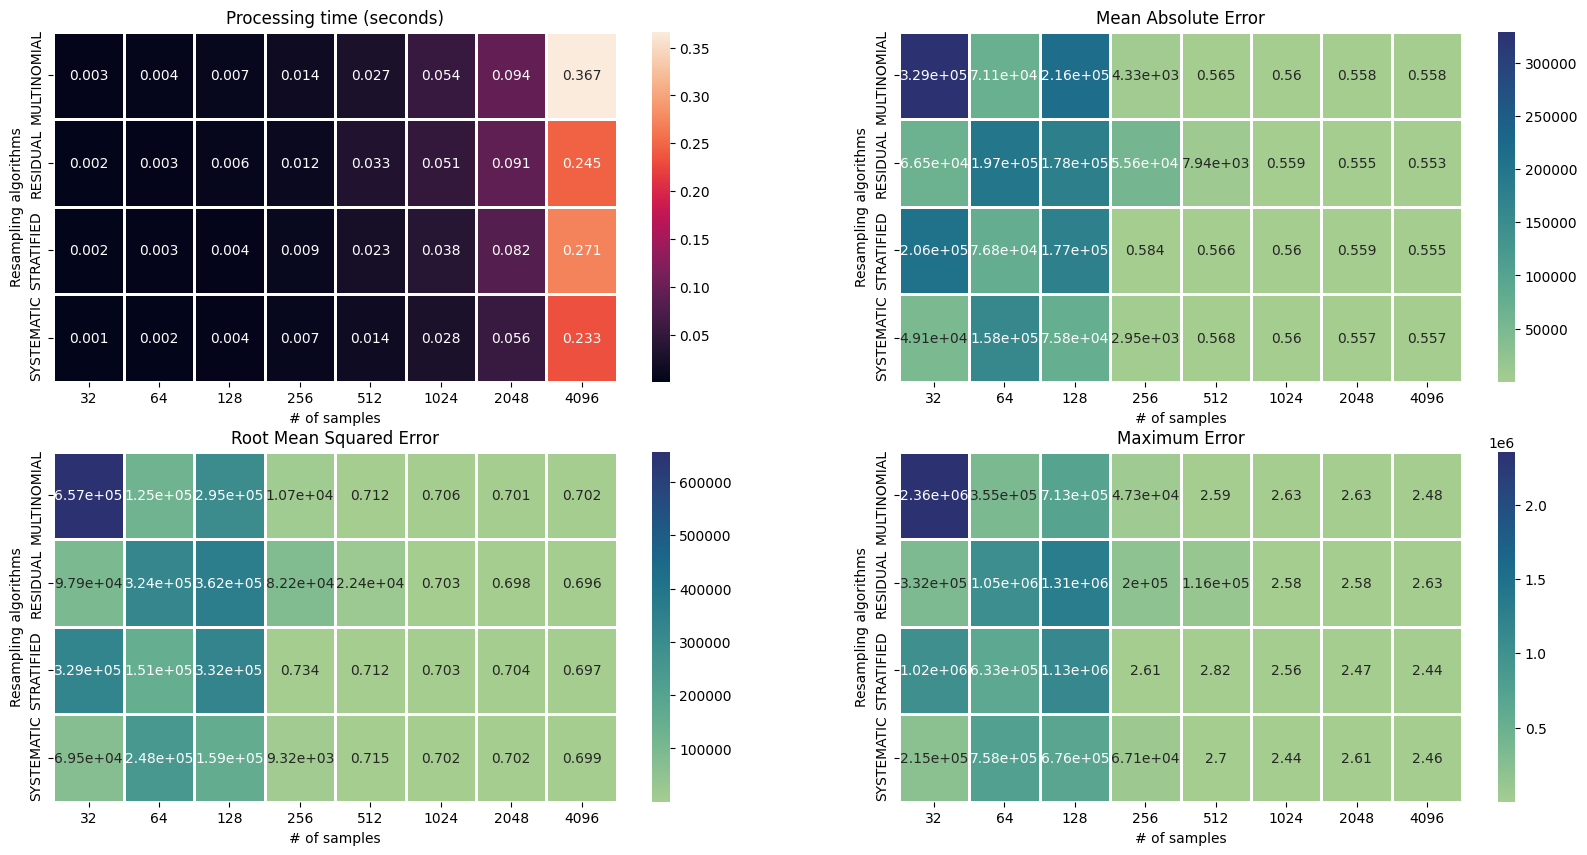

In [12]:
tuner_setup2.plot_results()

In [13]:
params_2_0, df_2_0 = tuner_setup2.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_0.append(params_2_0)

In [14]:
df_2_0

,# of samples,resampling algorithm
MAE,256,STRATIFIED
RMSE,256,STRATIFIED
MAX,256,STRATIFIED


## Setup3 (INS)

In [15]:
tuner_setup3 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.,
    gps_dropout_ratio=0.
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [16]:
if run_filter:
    tuner_setup3.run()
else:
    tuner_setup3.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:02<00:00, 45.31s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:04<00:00, 38.10s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:00<00:00, 37.60s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.74s/it]


Experiment finished.


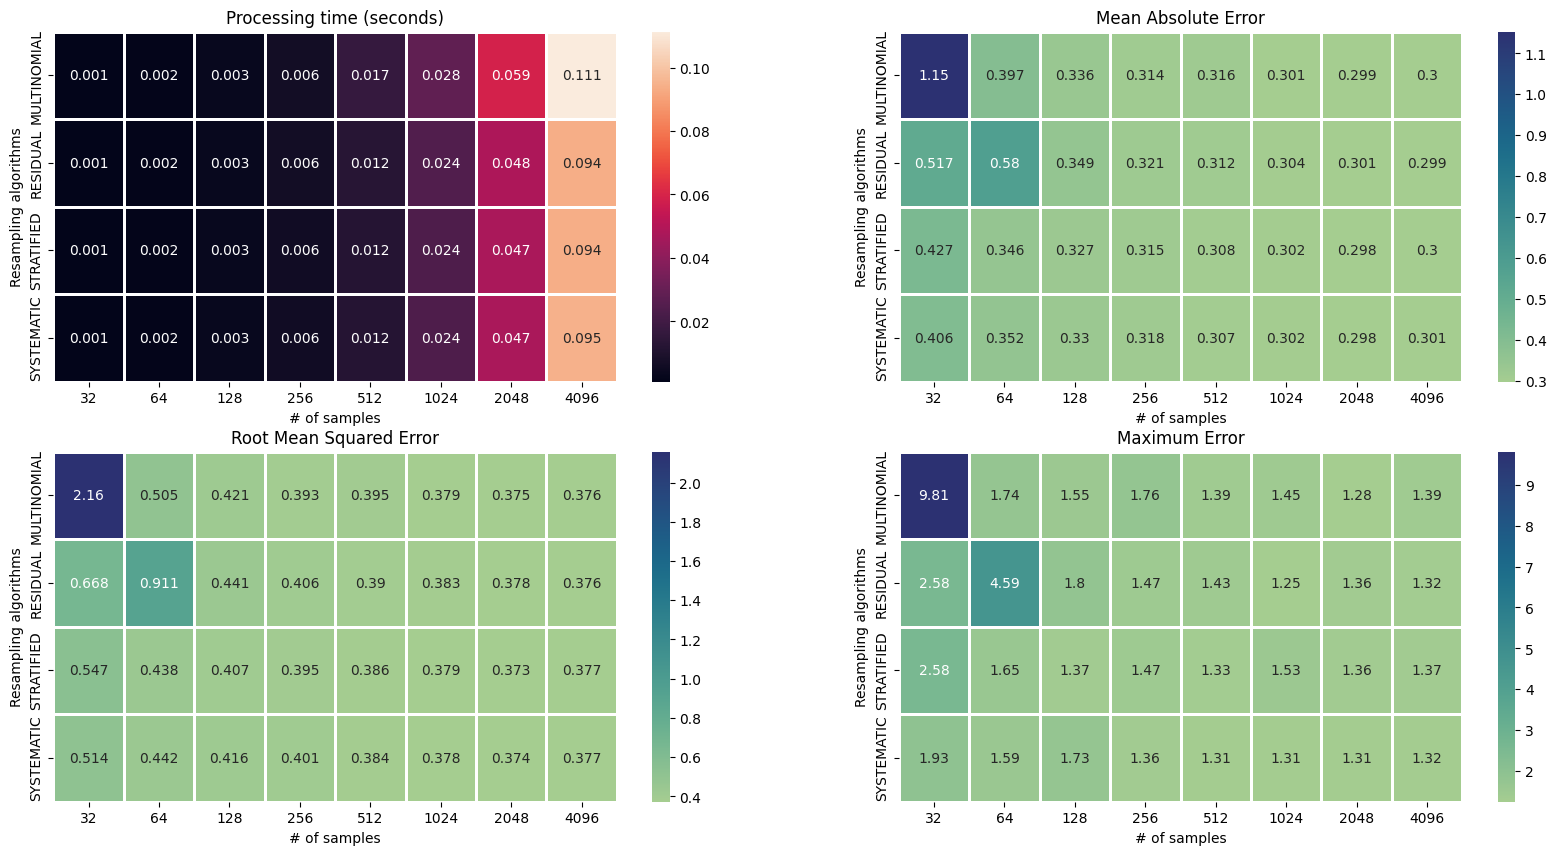

In [17]:
tuner_setup3.plot_results()

In [18]:
params_3_0, df_3_0 = tuner_setup3.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append(params_3_0)

In [19]:
df_3_0

,# of samples,resampling algorithm
MAE,256,MULTINOMIAL
RMSE,128,STRATIFIED
MAX,128,STRATIFIED


# 10% dropout measurement data

## Setup1 (IMU, VO)

In [20]:
tuner_setup1_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.1,
    gps_dropout_ratio=0.1
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [21]:
if run_filter:
    tuner_setup1_10.run()
else:
    tuner_setup1_10.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:47<00:00, 28.48s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:51<00:00, 28.97s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.07s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.10s/it]


Experiment finished.


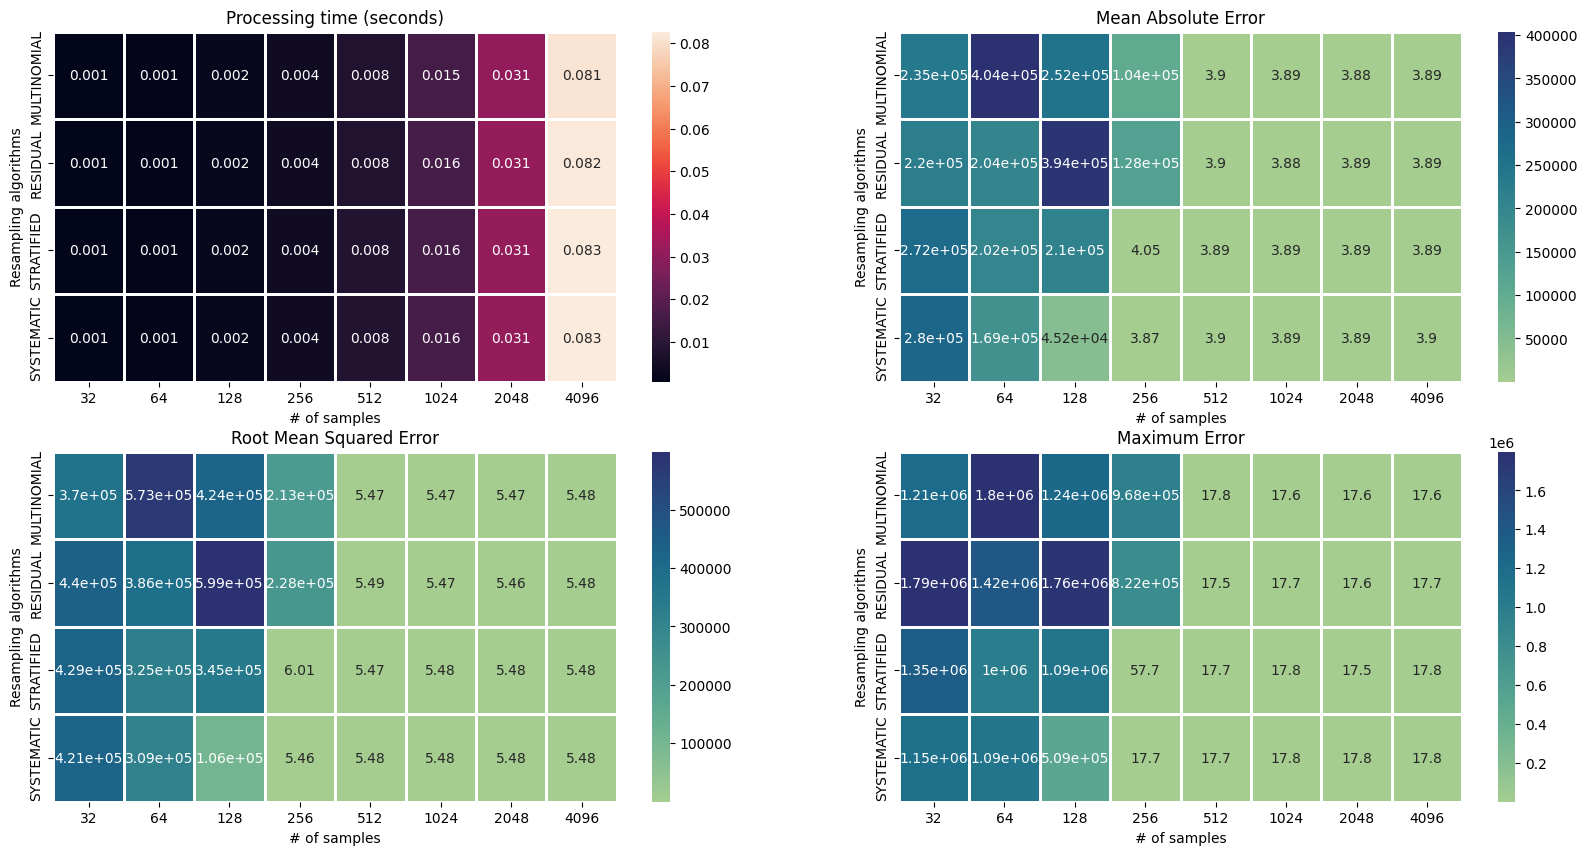

In [22]:
tuner_setup1_10.plot_results()

In [23]:
params_1_10, df_1_10 = tuner_setup1_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_1_10)

In [24]:
df_1_10

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,256,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [25]:
tuner_setup2_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.1,
    gps_dropout_ratio=0.1
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [26]:
if run_filter:
    tuner_setup2_10.run()
else:
    tuner_setup2_10.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:41<00:00, 50.19s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:43<00:00, 50.47s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:46<00:00, 50.81s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:45<00:00, 50.72s/it]


Experiment finished.


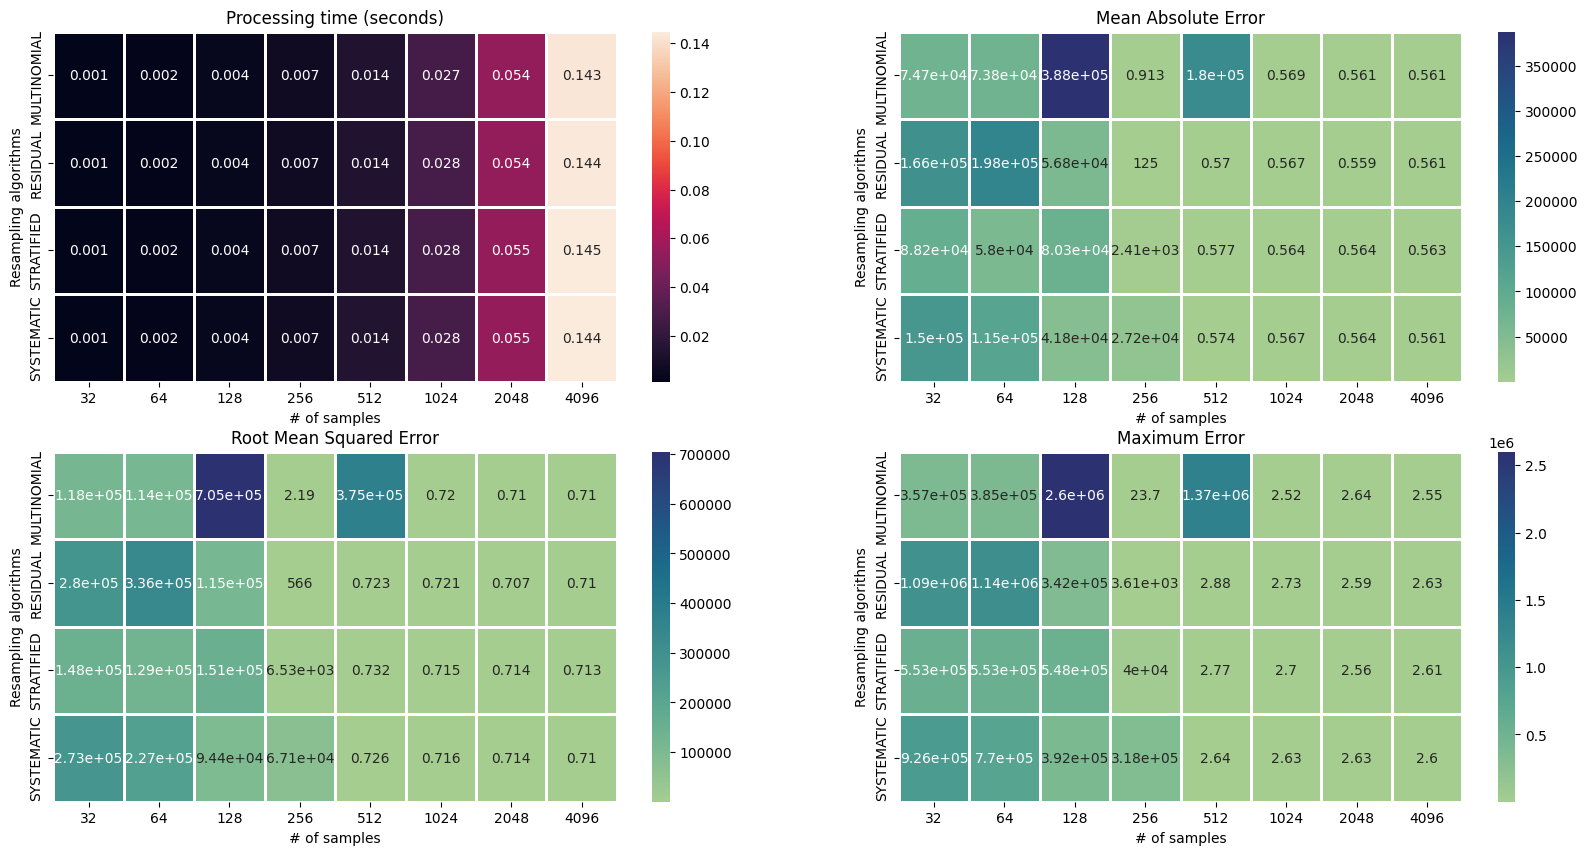

In [27]:
tuner_setup2_10.plot_results()

In [28]:
params_2_10, df_2_10 = tuner_setup2_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_2_10)

In [29]:
df_2_10

,# of samples,resampling algorithm
MAE,256,MULTINOMIAL
RMSE,256,MULTINOMIAL
MAX,512,RESIDUAL


## Setup3 (INS)

In [30]:
tuner_setup3_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.1,
    gps_dropout_ratio=0.1
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [31]:
if run_filter:
    tuner_setup3_10.run()
else:
    tuner_setup3_10.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:00<00:00, 37.59s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.63s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.70s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.65s/it]

Experiment finished.


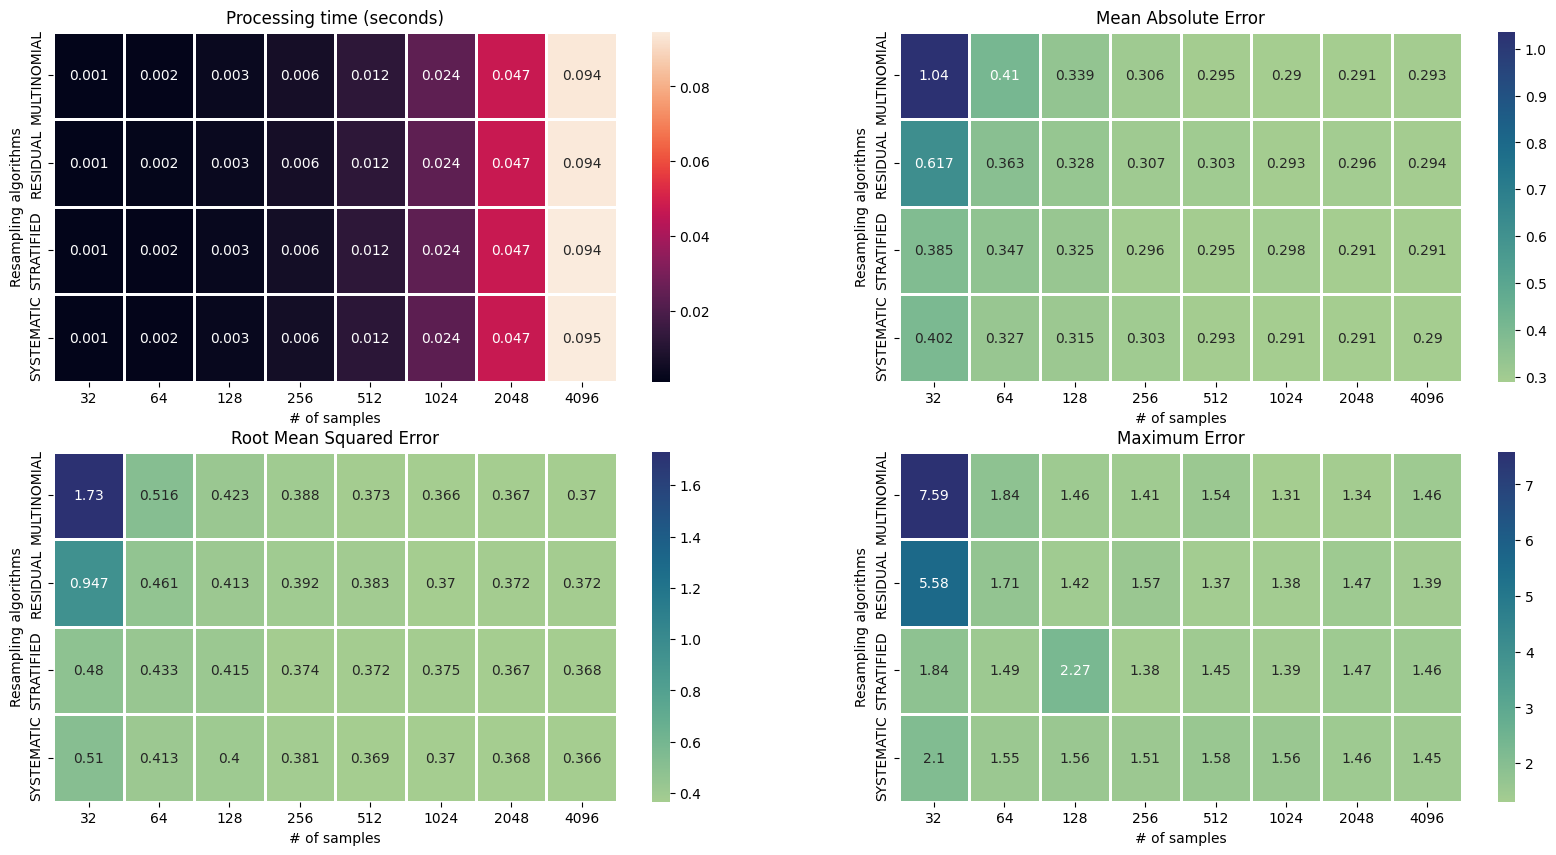

In [32]:
tuner_setup3_10.plot_results()

In [33]:
params_3_10, df_3_10 = tuner_setup3_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_3_10)

In [34]:
df_3_10

,# of samples,resampling algorithm
MAE,256,STRATIFIED
RMSE,256,STRATIFIED
MAX,128,RESIDUAL


# 20% dropout measurement data

## Setup1 (IMU, VO)

In [35]:
tuner_setup1_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.2,
    gps_dropout_ratio=0.2
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [36]:
if run_filter:
    tuner_setup1_20.run()
else:
    tuner_setup1_20.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:48<00:00, 28.57s/it]


Resampling by $RESIDUAL


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [35:11<00:00, 263.94s/it]


Resampling by $STRATIFIED


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [30:47<00:00, 230.90s/it]


Resampling by $SYSTEMATIC


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [34:43<00:00, 260.41s/it]


Experiment finished.


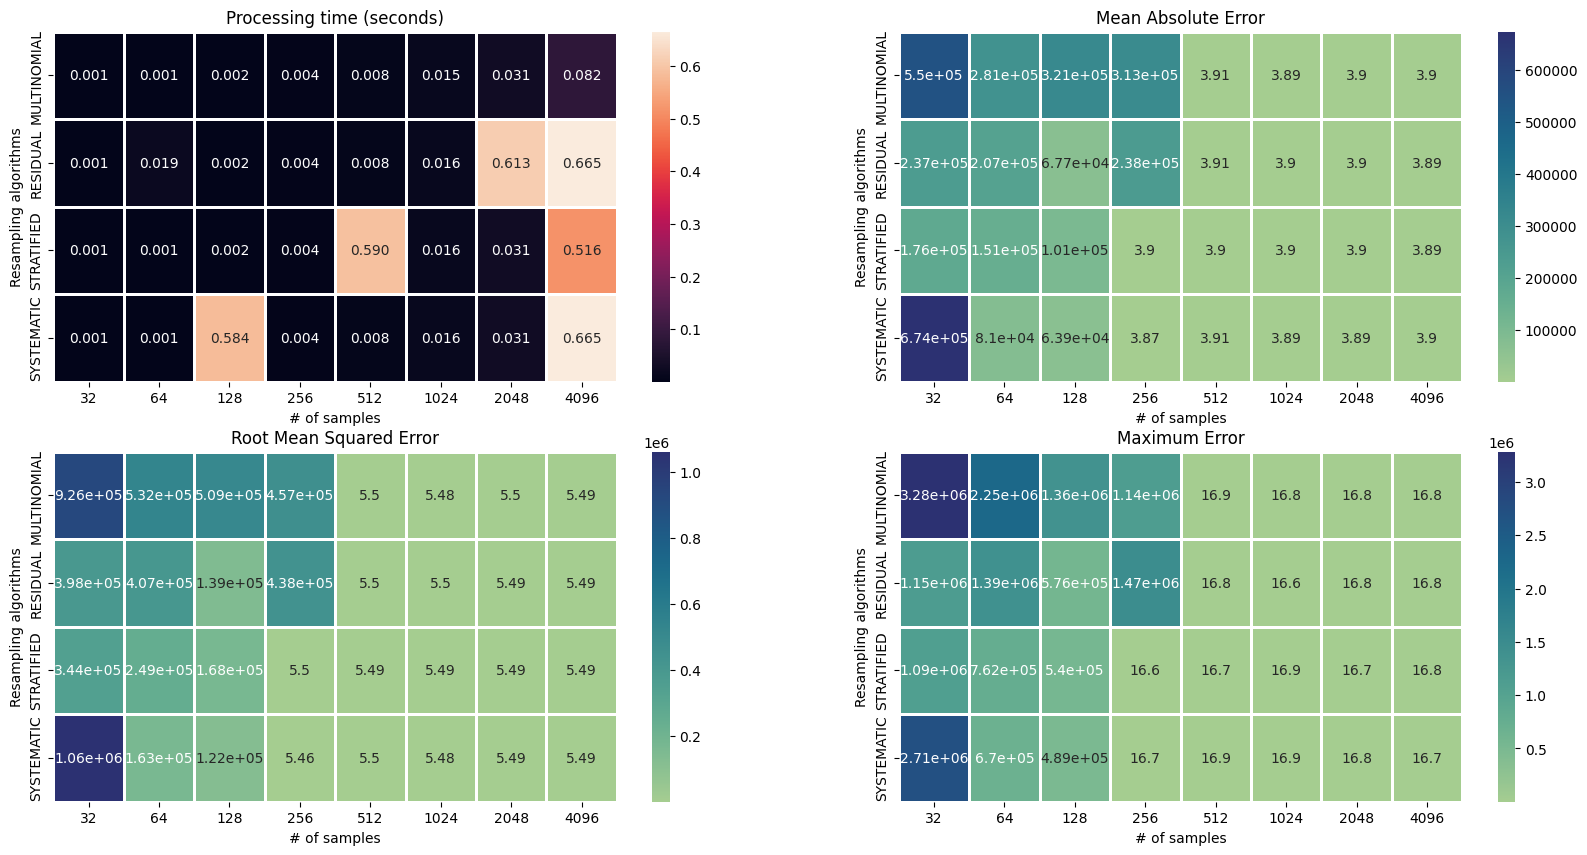

In [37]:
tuner_setup1_20.plot_results()

In [38]:
params_1_20, df_1_20 = tuner_setup1_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_1_20)

In [39]:
df_1_20

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,256,STRATIFIED


## Setup2 (IMU, VO+GPS)

In [40]:
tuner_setup2_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.2,
    gps_dropout_ratio=0.2
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [41]:
if run_filter:
    tuner_setup2_20.run()
else:
    tuner_setup2_20.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [08:33<00:00, 64.13s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:02<00:00, 52.86s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:09<00:00, 53.64s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:46<00:00, 50.85s/it]


Experiment finished.


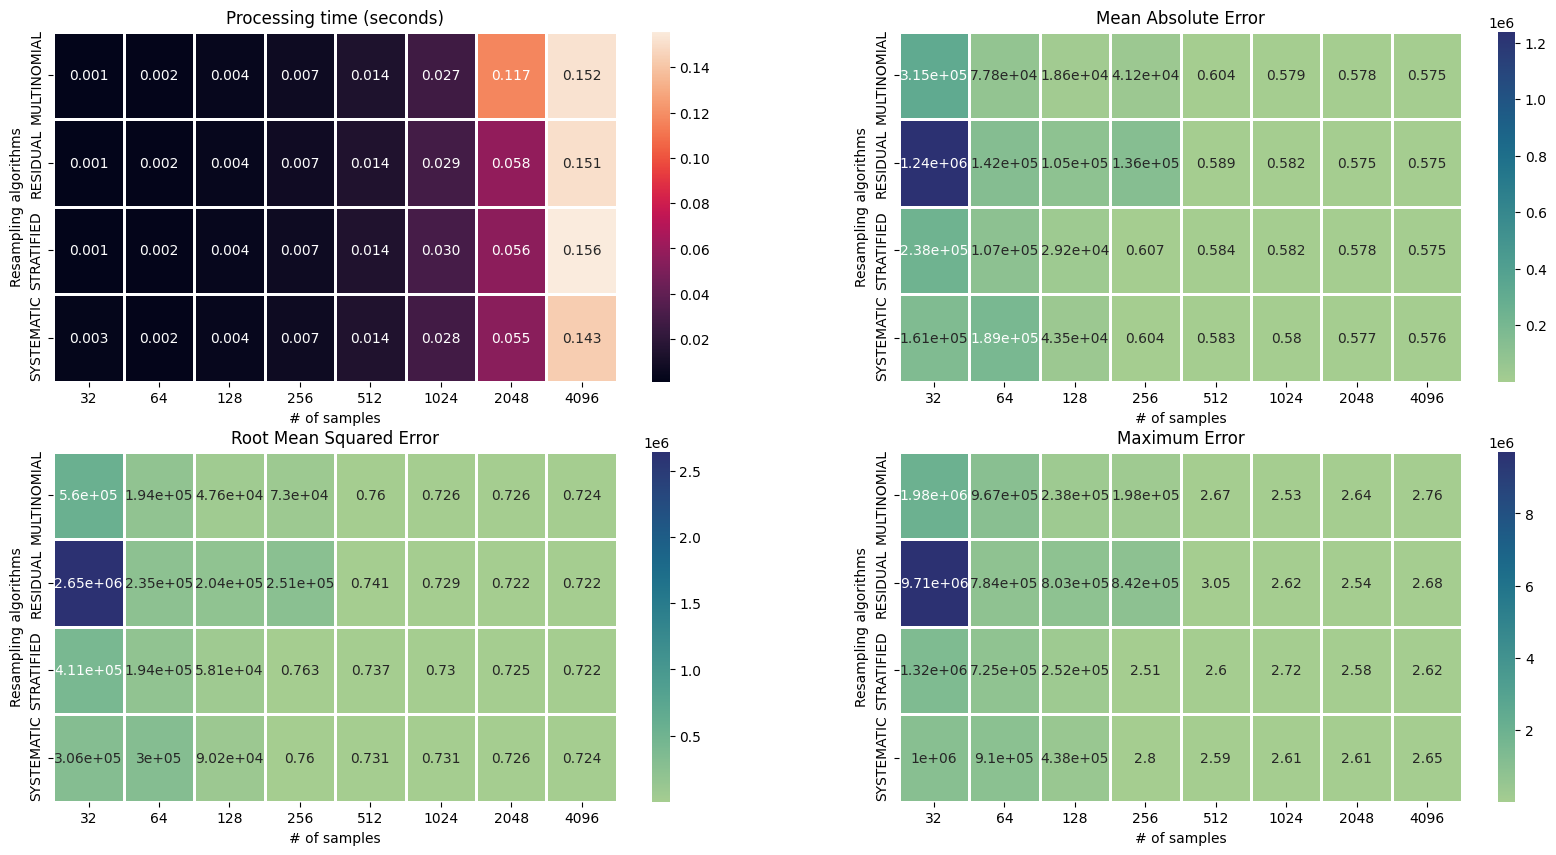

In [42]:
tuner_setup2_20.plot_results()

In [43]:
params_2_20, df_2_20 = tuner_setup2_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_2_20)

In [44]:
df_1_20

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,256,STRATIFIED


## Setup3 (INS)

In [45]:
tuner_setup3_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.2,
    gps_dropout_ratio=0.2
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [46]:
if run_filter:
    tuner_setup3_20.run()
else:
    tuner_setup3_20.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.73s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:00<00:00, 37.51s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.70s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.63s/it]

Experiment finished.


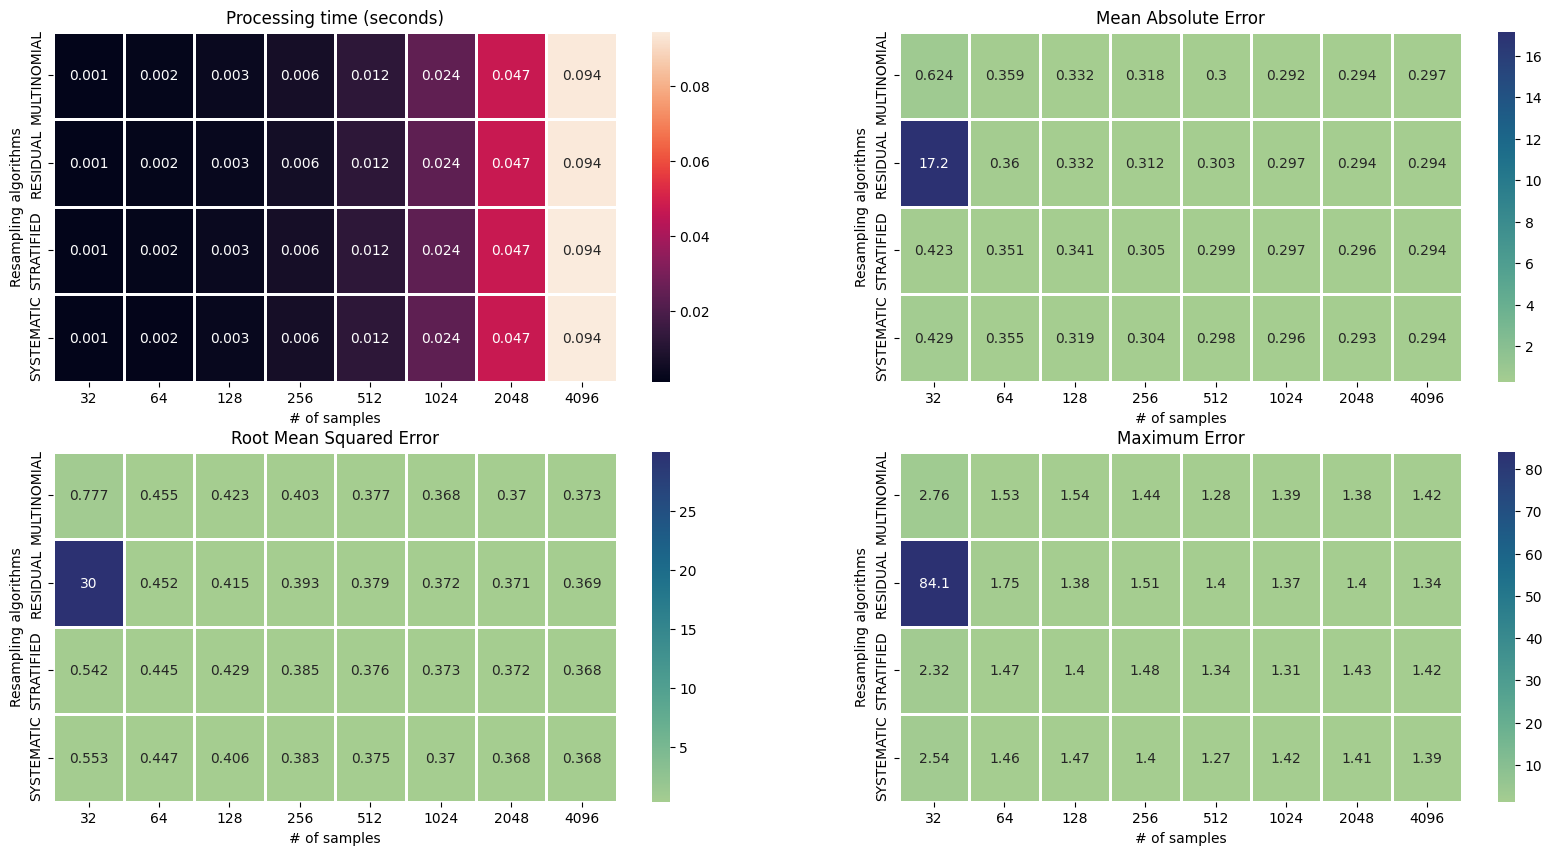

In [47]:
tuner_setup3_20.plot_results()

In [48]:
params_3_20, df_3_20 = tuner_setup3_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_3_20)

In [49]:
df_3_20

,# of samples,resampling algorithm
MAE,64,STRATIFIED
RMSE,64,STRATIFIED
MAX,64,SYSTEMATIC


# 30% dropout measurement data

## Setup1 (IMU, VO)

In [50]:
tuner_setup1_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.3,
    gps_dropout_ratio=0.3
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [51]:
if run_filter:
    tuner_setup1_30.run()
else:
    tuner_setup1_30.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:48<00:00, 28.55s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:50<00:00, 28.84s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.06s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.03s/it]

Experiment finished.


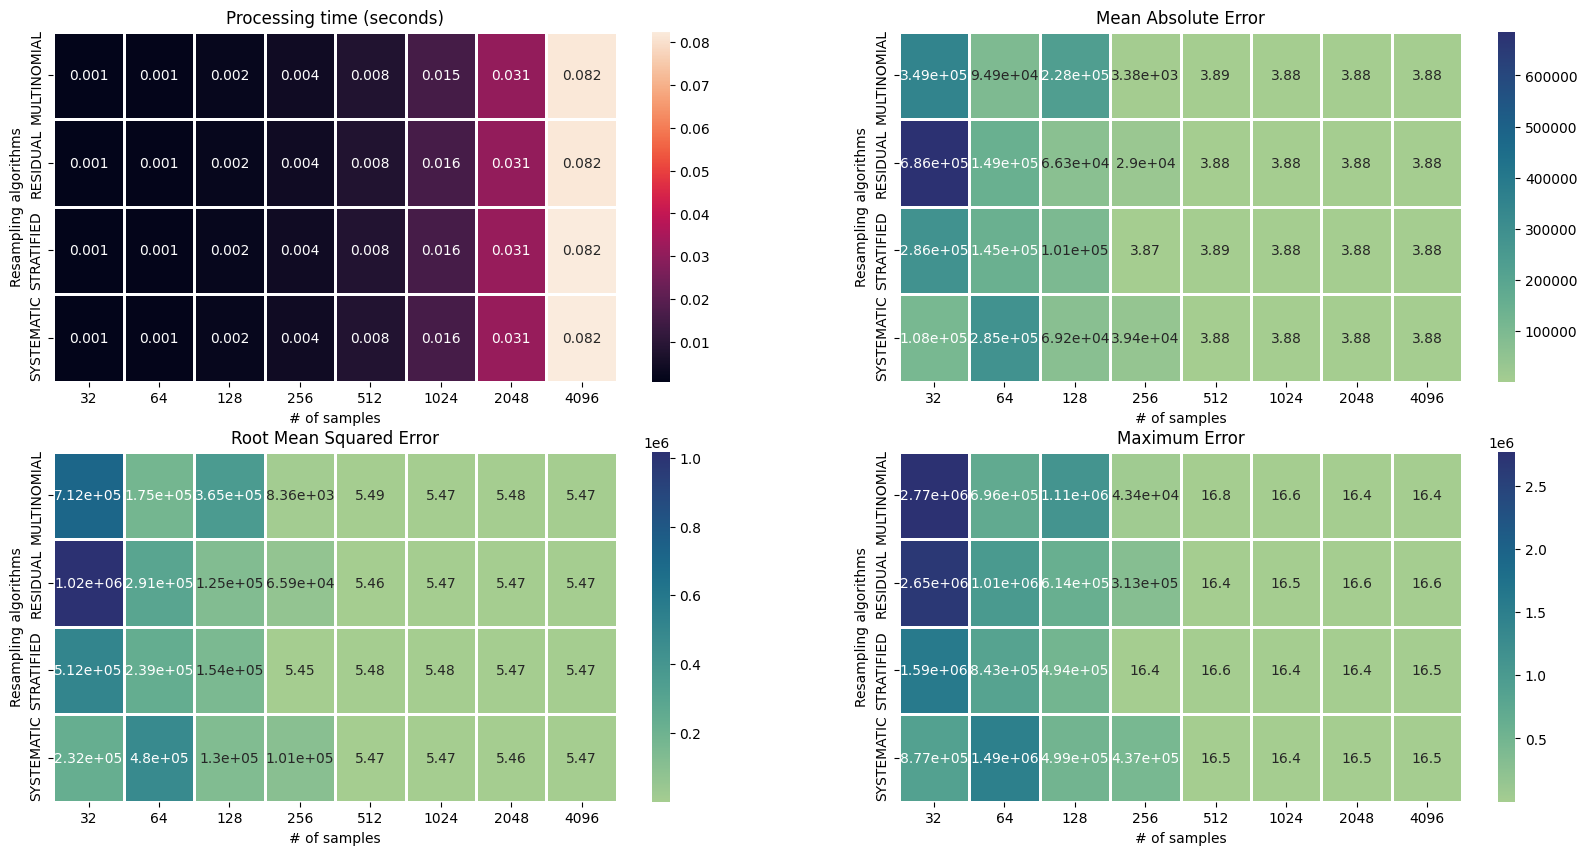

In [52]:
tuner_setup1_30.plot_results()

In [53]:
params_1_30, df_1_30 = tuner_setup1_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_1_30)

In [54]:
df_1_30

,# of samples,resampling algorithm
MAE,256,STRATIFIED
RMSE,256,STRATIFIED
MAX,256,STRATIFIED


## Setup2 (IMU, VO+GPS)

In [55]:
tuner_setup2_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.3,
    gps_dropout_ratio=0.3
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [56]:
if run_filter:
    tuner_setup2_30.run()
else:
    tuner_setup2_30.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:40<00:00, 50.09s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:43<00:00, 50.46s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:17<00:00, 54.64s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:48<00:00, 51.06s/it]

Experiment finished.


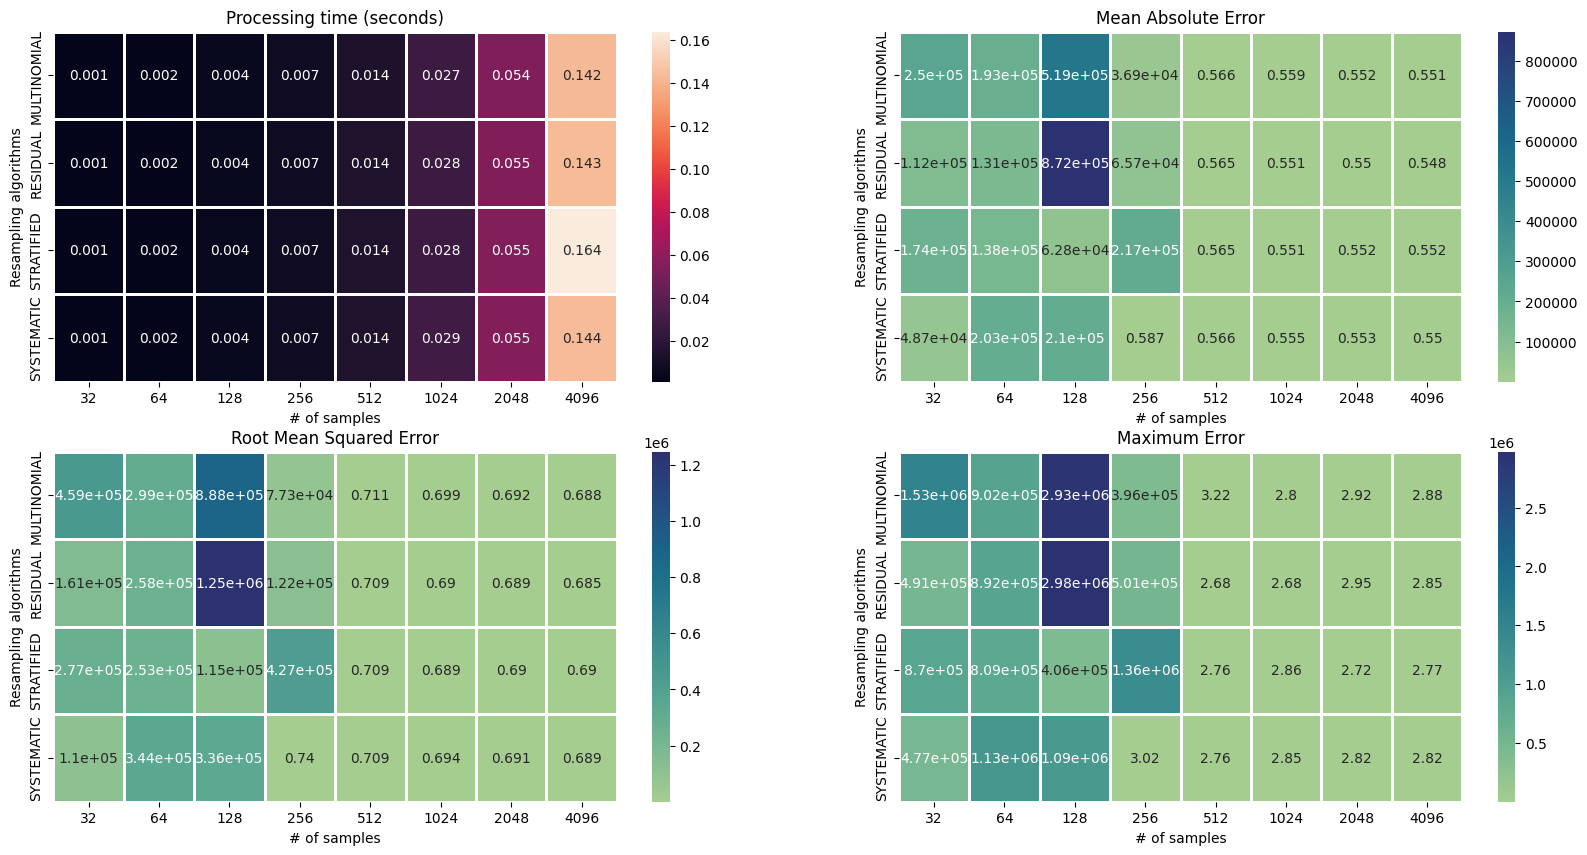

In [57]:
tuner_setup2_30.plot_results()

In [58]:
params_2_30, df_2_30 = tuner_setup2_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_2_30)

In [59]:
df_2_30

,# of samples,resampling algorithm
MAE,256,SYSTEMATIC
RMSE,256,SYSTEMATIC
MAX,256,SYSTEMATIC


## Setup3 (INS)

In [60]:
tuner_setup3_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.3,
    gps_dropout_ratio=0.3
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [61]:
if run_filter:
    tuner_setup3_30.run()
else:
    tuner_setup3_30.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.64s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:00<00:00, 37.54s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:02<00:00, 37.81s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:01<00:00, 37.73s/it]

Experiment finished.


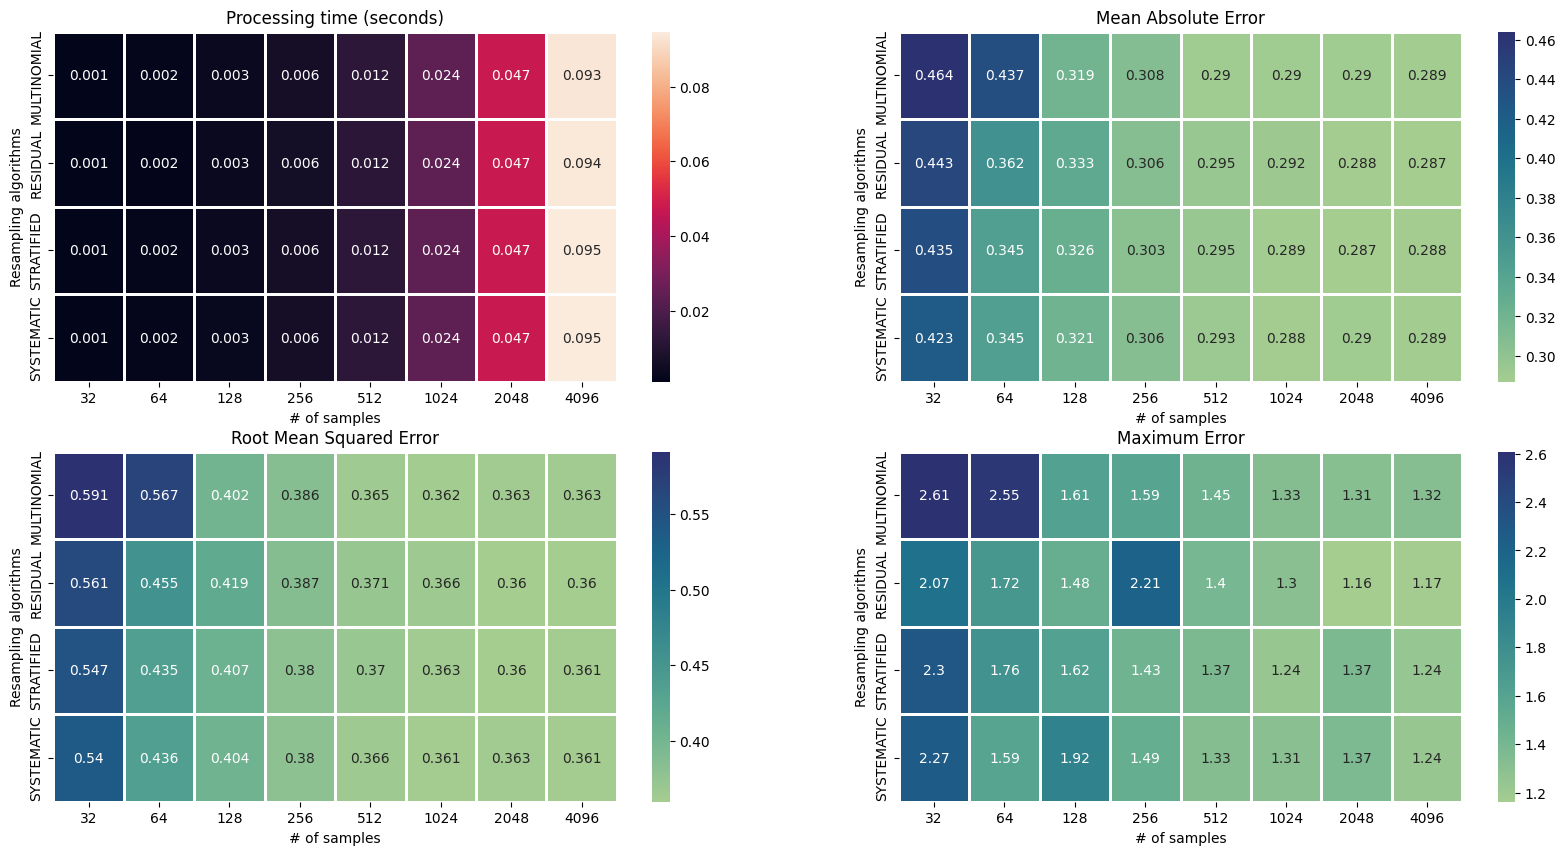

In [62]:
tuner_setup3_30.plot_results()

In [63]:
params_3_30, df_3_30 = tuner_setup3_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_3_30)

In [64]:
df_3_30

,# of samples,resampling algorithm
MAE,512,MULTINOMIAL
RMSE,512,MULTINOMIAL
MAX,1024,STRATIFIED


# 40% dropout measurement data

## Setup1 (IMU, VO)

In [65]:
tuner_setup1_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.4,
    gps_dropout_ratio=0.4
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [66]:
if run_filter:
    tuner_setup1_40.run()
else:
    tuner_setup1_40.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:47<00:00, 28.47s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.08s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:53<00:00, 29.23s/it]


Resampling by $SYSTEMATIC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.07s/it]

Experiment finished.


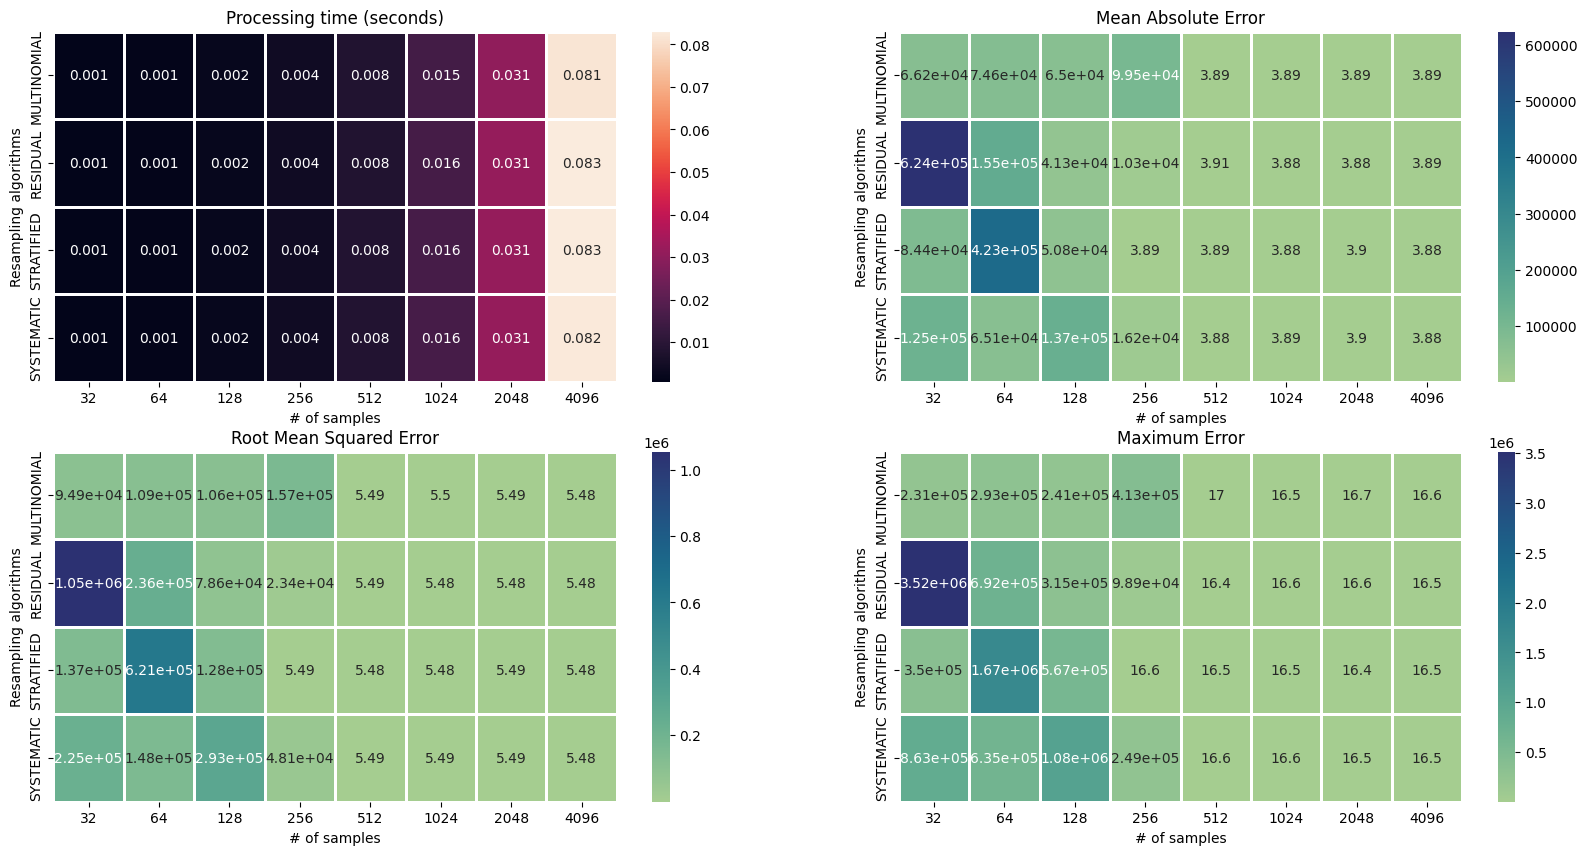

In [67]:
tuner_setup1_40.plot_results()

In [68]:
params_1_40, df_1_40 = tuner_setup1_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_1_40)

In [69]:
df_1_40

,# of samples,resampling algorithm
MAE,256,STRATIFIED
RMSE,256,STRATIFIED
MAX,256,STRATIFIED


## Setup2 (IMU, VO+GPS)

In [70]:
tuner_setup2_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.4,
    gps_dropout_ratio=0.4
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [71]:
if run_filter:
    tuner_setup2_40.run()
else:
    tuner_setup2_40.load_df()

Resampling by $MULTINOMIAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:44<00:00, 50.54s/it]


Resampling by $RESIDUAL


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:45<00:00, 50.73s/it]


Resampling by $STRATIFIED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [07:16<00:00, 54.53s/it]


Resampling by $SYSTEMATIC


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [37:25<00:00, 280.73s/it]

Experiment finished.


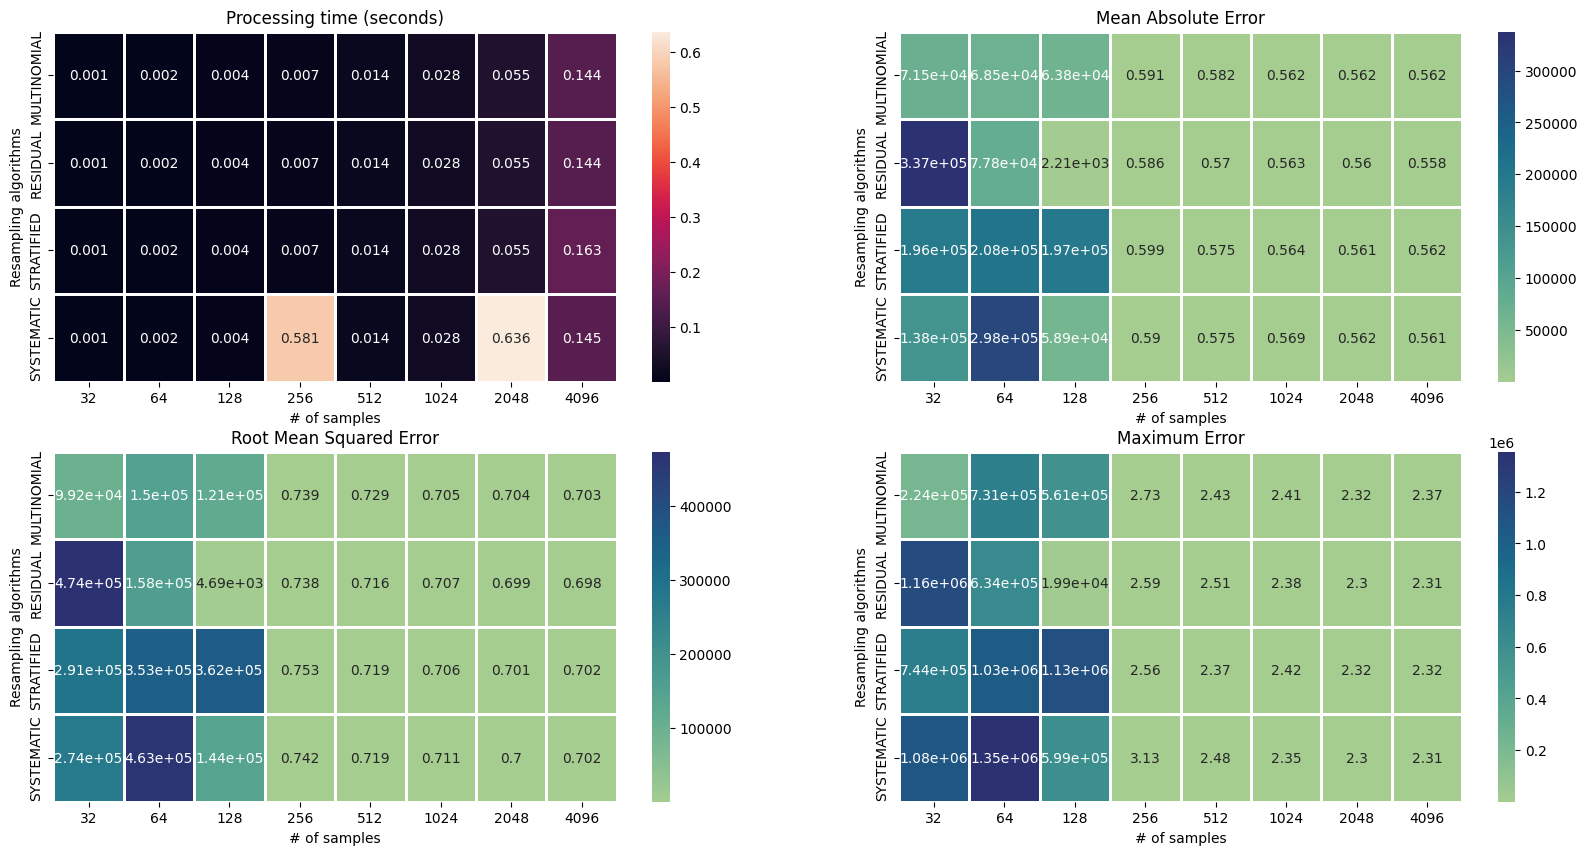

In [72]:
tuner_setup2_40.plot_results()

In [73]:
params_2_40, df_2_40 = tuner_setup2_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_2_40)

In [74]:
df_2_40

,# of samples,resampling algorithm
MAE,256,MULTINOMIAL
RMSE,256,MULTINOMIAL
MAX,256,STRATIFIED


## Setup3 (INS)

In [75]:
tuner_setup3_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    vo_dropout_ratio=0.4,
    gps_dropout_ratio=0.4
)

{'n_samples': [32, 64, 128, 256, 512, 1024, 2048, 4096], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
MeasurementDataEnum.ALL_DATA
Data sampling is set to normal mode.


In [76]:
if run_filter:
    tuner_setup3_40.run()
else:
    tuner_setup3_40.load_df()

Resampling by $MULTINOMIAL


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [21:22<00:00, 160.28s/it]


Resampling by $RESIDUAL


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [20:20<00:00, 152.56s/it]


Resampling by $STRATIFIED


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [35:36<00:00, 267.03s/it]


Resampling by $SYSTEMATIC


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [20:28<00:00, 153.56s/it]

Experiment finished.


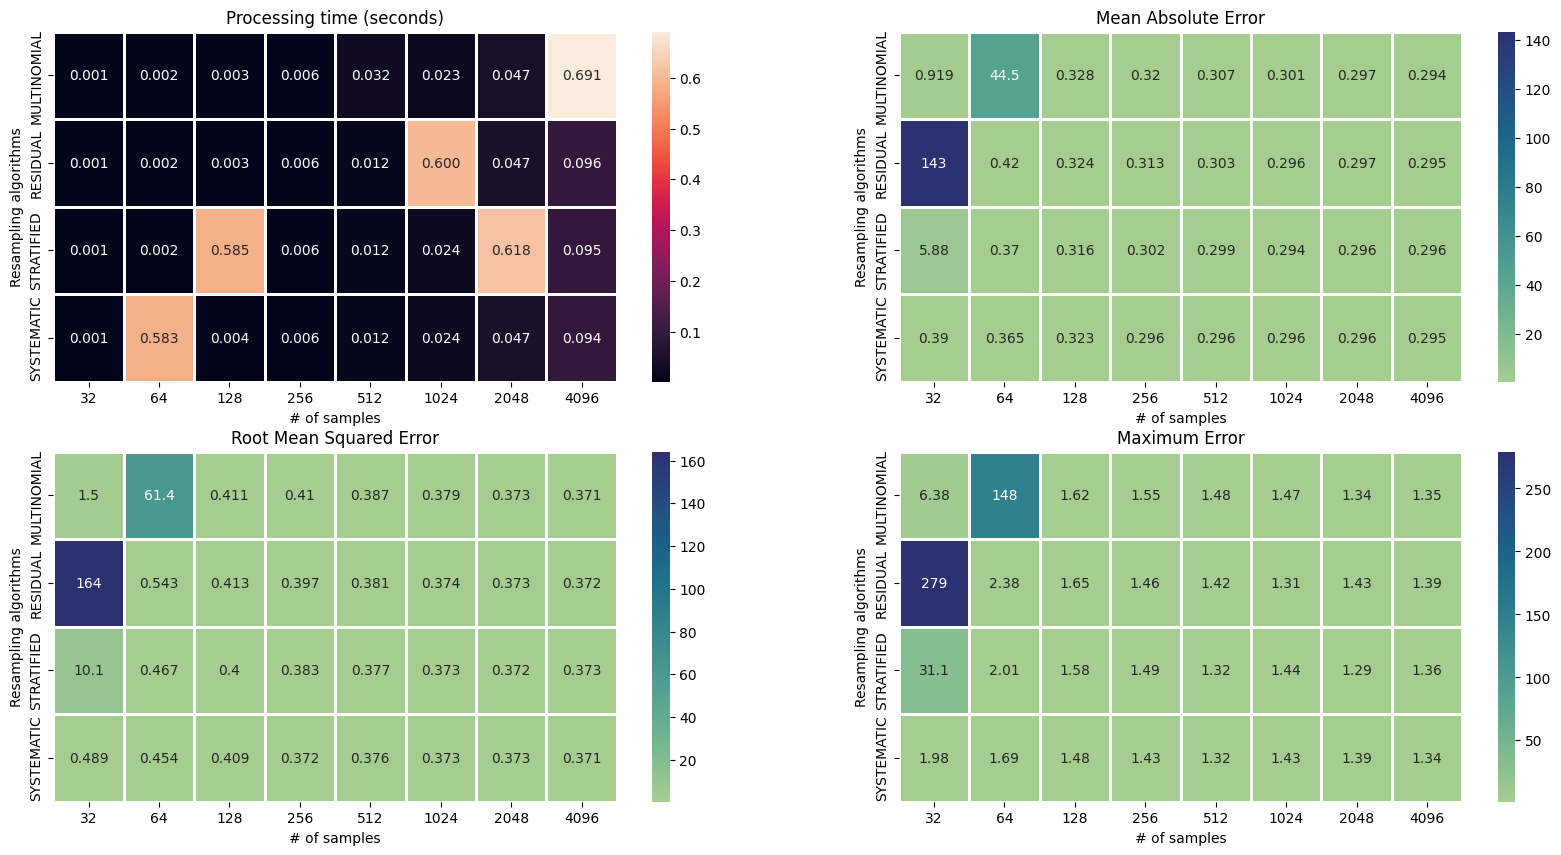

In [77]:
tuner_setup3_40.plot_results()

In [78]:
params_3_40, df_3_40 = tuner_setup3_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_3_40)

In [79]:
df_3_40

,# of samples,resampling algorithm
MAE,32,SYSTEMATIC
RMSE,32,SYSTEMATIC
MAX,128,SYSTEMATIC


# Results

In [80]:
best_params_0_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_0_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_0_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_10_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_10_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_10_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_20_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_20_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_20_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_30_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_30_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_30_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_40_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_40_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_40_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_mae = [best_params_0_mae, best_params_10_mae, best_params_20_mae, best_params_30_mae, best_params_40_mae]
best_params_rmse = [best_params_0_rmse, best_params_10_rmse, best_params_20_rmse, best_params_30_rmse, best_params_40_rmse]
best_params_max = [best_params_0_max, best_params_10_max, best_params_20_max, best_params_30_max, best_params_40_max]

In [81]:
best_params_mae

[['256', 'SYSTEMATIC', '256', 'STRATIFIED', '256', 'MULTINOMIAL'],
 ['256', 'SYSTEMATIC', '256', 'MULTINOMIAL', '256', 'STRATIFIED'],
 ['256', 'SYSTEMATIC', '256', 'SYSTEMATIC', '64', 'STRATIFIED'],
 ['256', 'STRATIFIED', '256', 'SYSTEMATIC', '512', 'MULTINOMIAL'],
 ['256', 'STRATIFIED', '256', 'MULTINOMIAL', '32', 'SYSTEMATIC']]

In [82]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS)'],
                                             ['# of samples', 'Resampling algorithm']],
                                            names=['Setups','Parameters'])


#### MAE

In [83]:
pd.DataFrame(best_params_mae, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              256           SYSTEMATIC                 256   
10% drop                256           SYSTEMATIC                 256   
20% drop                256           SYSTEMATIC                 256   
30% drop                256           STRATIFIED                 256   
40% drop                256           STRATIFIED                 256   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout           STRATIFIED          256          MULTINOMIAL  
10% drop            MULTINOMIAL          256           STRATIFIED  
20% drop             SYSTEMATIC           64           STRATIFIED  
30% drop             SYSTEMATIC          512          MULTINOMIAL  
40% drop            MULTINOMIAL           32           SYSTEMATIC

#### RMSE

In [84]:
pd.DataFrame(best_params_rmse, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              256           SYSTEMATIC                 256   
10% drop                256           SYSTEMATIC                 256   
20% drop                256           SYSTEMATIC                 256   
30% drop                256           STRATIFIED                 256   
40% drop                256           STRATIFIED                 256   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout           STRATIFIED          128           STRATIFIED  
10% drop            MULTINOMIAL          256           STRATIFIED  
20% drop             SYSTEMATIC           64           STRATIFIED  
30% drop             SYSTEMATIC          512          MULTINOMIAL  
40% drop            MULTINOMIAL           32           SYSTEMATIC

#### MAX

In [85]:
pd.DataFrame(best_params_max, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              256           SYSTEMATIC                 256   
10% drop                256           SYSTEMATIC                 512   
20% drop                256           STRATIFIED                 256   
30% drop                256           STRATIFIED                 256   
40% drop                256           STRATIFIED                 256   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout           STRATIFIED          128           STRATIFIED  
10% drop               RESIDUAL          128             RESIDUAL  
20% drop             STRATIFIED           64           SYSTEMATIC  
30% drop             SYSTEMATIC         1024           STRATIFIED  
40% drop             STRATIFIED          128           SYSTEMATIC